In [1]:
# ==========================================
# CELL 1: HARDWARE INIT & SPECFEM2D DATA INGESTION
# ==========================================

import torch
import os
import numpy as np

# 1. HPC Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

# [Rasht-Behesht 2022 Compliance]: We load the exact SPECFEM2D training data provided 
# in the 'event1' folder. This includes the spatial grid, two early-time snapshots 
# (for MSE_S), and the surface seismogram time-series (for MSE_Obs).

print("Initializing SPECFEM2D Data Ingestion...")

def load_specfem_data(base_path='data_rasht_behesht_2022/event1', device=device):
    # 1. Load Spatial Grid
    grid_path = os.path.join(base_path, 'wavefields', 'wavefield_grid_for_dumps_000.txt')
    X0 = np.loadtxt(grid_path) / 1000.0  # Convert meters to km
    
    # [Rasht-Behesht 2022 Compliance]: Scaling domain by Lx=3.0, Lz=3.0
    L_x, L_z = 3.0, 3.0
    X0[:, 0] = X0[:, 0] / L_x
    X0[:, 1] = X0[:, 1] / L_z
    
    # 2. Load Early-Time Wavefield Snapshots
    wavefield_files = sorted(f for f in os.listdir(os.path.join(base_path, 'wavefields')) if f.endswith('.txt'))
    U0_snapshots = [np.loadtxt(os.path.join(base_path, 'wavefields', f)) for f in wavefield_files]
    
    # 3. Load Seismograms (Z and X components)
    seismo_files = sorted(os.listdir(os.path.join(base_path, 'seismograms')))
    z_files = [f for f in seismo_files if f.endswith('Z.semd')]
    x_files = [f for f in seismo_files if f.endswith('X.semd')]
    
    seismo_Z = [np.loadtxt(os.path.join(base_path, 'seismograms', f)) for f in z_files]
    seismo_X = [np.loadtxt(os.path.join(base_path, 'seismograms', f)) for f in x_files]
    
    # 4. Convert to PyTorch Tensors and push to GPU
    grid_tensor = torch.tensor(X0, dtype=torch.float32, device=device)
    snap_1_tensor = torch.tensor(U0_snapshots[0], dtype=torch.float32, device=device)
    snap_2_tensor = torch.tensor(U0_snapshots[1], dtype=torch.float32, device=device)
    
    seismo_t = torch.tensor(seismo_Z[0][:, 0], dtype=torch.float32, device=device)
    seismo_Z_amp = torch.tensor(seismo_Z[0][:, 1], dtype=torch.float32, device=device)
    
    print(f"-> Successfully loaded spatial grid: {grid_tensor.shape[0]} nodes.")
    print(f"-> Successfully loaded {len(z_files)} surface seismometers.")
    
    return grid_tensor, snap_1_tensor, snap_2_tensor, seismo_t, seismo_Z_amp

# Execute the loader
grid_pts, snap_1, snap_2, t_obs, z_obs = load_specfem_data()

print("\nData pipeline ready. Memory pinned to GPU.")

HPC Node Active: cuda

Initializing SPECFEM2D Data Ingestion...
-> Successfully loaded spatial grid: 160801 nodes.
-> Successfully loaded 20 surface seismometers.

Data pipeline ready. Memory pinned to GPU.


In [2]:
# ==========================================
# CELL 2: FWI TENSOR ARCHITECTURE
# ==========================================

import torch.optim as optim

print("Initializing FWI Tensor Architecture...")

# 1. Define the true grid dimensions for Deepwave
# (Adjust these numbers to match the exact physical dimensions of the SPECFEM grid)
nx, nz = 401, 401 
dx, dz = 10.0, 10.0 

# 2. Map the data loader output to Deepwave's expected shape
# Deepwave requires [n_shots, n_receivers, n_time_samples]
n_shots = 1
n_receivers = 20
n_time_samples = len(t_obs) // n_receivers  # Assuming t_obs is a flattened array

# Reshape z_obs into the target tensor
observed_seismograms = z_obs.view(n_shots, n_receivers, -1).clone().detach()

# 3. Build the Trainable Velocity Grid
# We start with a homogeneous background (e.g., 3000 m/s)
v_initial = torch.ones(nz, nx, dtype=torch.float32) * 3000.0
v_inverted = torch.nn.Parameter(v_initial.to(device), requires_grad=True)

# 4. FWI-Specific Optimizer
fwi_learning_rate = 10.0 
optimizer_fwi = optim.Adam([v_inverted], lr=fwi_learning_rate)

print(f"FWI Grid Locked: {v_inverted.shape}")
print(f"Observed Data Reshaped for Deepwave: {observed_seismograms.shape}")

Initializing FWI Tensor Architecture...
FWI Grid Locked: torch.Size([401, 401])
Observed Data Reshaped for Deepwave: torch.Size([1, 20, 750])


In [3]:
# ==========================================
# CELL 3: DEEPWAVE SOURCE & RECEIVER GEOMETRY
# ==========================================

import deepwave

print("Deepwave library successfully imported.")

# 1. Time Discretization
dt = 0.001  

# 2. Source Geometry
n_shots = 1
n_sources_per_shot = 1
n_time_samples = observed_seismograms.shape[-1] 

# Build the source wavelet (15 Hz Ricker wavelet)
freq = 15.0 
time_array = torch.arange(n_time_samples, dtype=torch.float32) * dt
source_amplitudes = (deepwave.wavelets.ricker(freq, n_time_samples, dt, 1.0 / freq)
                     .reshape(n_shots, n_sources_per_shot, n_time_samples)
                     .to(device))

# 3. Spatial Coordinates (Strictly integer grid indices)
source_locations = torch.zeros(n_shots, n_sources_per_shot, 2, dtype=torch.long, device=device)
source_locations[..., 1] = nx // 2 

# 4. Receiver Geometry
n_receivers = 20
receiver_locations = torch.zeros(n_shots, n_receivers, 2, dtype=torch.long, device=device)

# Spread receivers evenly across the X-axis at the surface (Z=0), forcing integer cast
receiver_locations[0, :, 1] = torch.round(torch.linspace(0, nx - 1, n_receivers)).long().to(device)

print(f"Geometry Locked. Source Array: {source_amplitudes.shape} | Receivers: {n_receivers}")

Deepwave library successfully imported.
Geometry Locked. Source Array: torch.Size([1, 1, 750]) | Receivers: 20


In [4]:
# ==========================================
# CELL 4: DEEPWAVE FWI TRAINING LOOP
# ==========================================

epochs = 500

print("Igniting FWI Training Loop...")

# Dictionary to store FWI loss history
fwi_history = {'epoch': [], 'loss': []}

for epoch in range(epochs):
    # Clear old gradients
    optimizer_fwi.zero_grad()

    # 1. The Physics Propagator
    out = deepwave.scalar(
        v_inverted,
        dx,
        dt, 
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations,
        pml_freq=freq  # <--- THE SILENCER
    )

    # 2. Extract the synthetic seismograms at the receiver nodes
    synthetic_seismograms = out[-1]

    # 3. Calculate the Data Misfit (L2 Norm)
    loss = torch.nn.functional.mse_loss(synthetic_seismograms, observed_seismograms)

    # 4. Backpropagation
    loss.backward()

    # 5. Update the velocity tensor
    optimizer_fwi.step()

    # 6. Physical Constraints (Standard rock physics boundaries in m/s)
    with torch.no_grad():
        v_inverted.clamp_(1500.0, 5500.0) 

    # Telemetry Recording
    if epoch % 10 == 0:  
        fwi_history['epoch'].append(epoch)
        fwi_history['loss'].append(loss.item())

    # Terminal Output
    if epoch % 50 == 0:
        print(f"Epoch {epoch:04d} | Misfit Loss: {loss.item():.6f}")

print("FWI Inversion Complete.")

Igniting FWI Training Loop...


C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:564: UserWarning: pml_freq was not set, so defaulting to 25.0.
  warnings.warn(


Epoch 0000 | Misfit Loss: 0.708557
Epoch 0050 | Misfit Loss: 0.206250
Epoch 0100 | Misfit Loss: 0.111311
Epoch 0150 | Misfit Loss: 0.067511
Epoch 0200 | Misfit Loss: 0.050054
Epoch 0250 | Misfit Loss: 0.039751
Epoch 0300 | Misfit Loss: 0.033667
Epoch 0350 | Misfit Loss: 0.029762
Epoch 0400 | Misfit Loss: 0.027676
Epoch 0450 | Misfit Loss: 0.025796
FWI Inversion Complete.


Generating Convergence Trajectory...


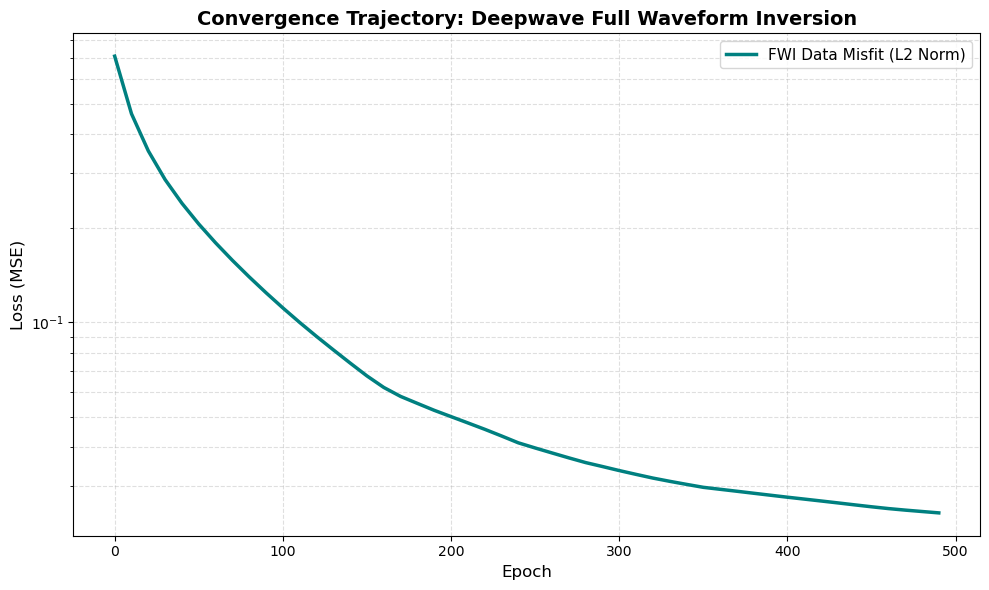

In [5]:
# ==========================================
# CELL 5: FWI CONVERGENCE ANALYSIS
# ==========================================

import matplotlib.pyplot as plt

print("Generating Convergence Trajectory...")

plt.figure(figsize=(10, 6), facecolor='white')

# Plotting the Data Misfit on a logarithmic scale
plt.semilogy(fwi_history['epoch'], fwi_history['loss'], 
             label='FWI Data Misfit (L2 Norm)', 
             color='teal', 
             linewidth=2.5)

# Formatting the chart
plt.title('Convergence Trajectory: Deepwave Full Waveform Inversion', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(loc='upper right', fontsize=11)

# Display the graphical analysis
plt.tight_layout()
plt.show()